# Notebook 5 — What it actually takes to prove causation

Notebook 4 ended with `calls_made` genuinely unresolved: it survives every check observational data can offer — no confounding from territory, consistent across territory bands — and yet an equally plausible non-causal story (reverse causation) explains the exact same pattern. No amount of additional regression on this dataset can break that tie.

This notebook explains why, and closes the series:

- **Part A** shows *why* randomization specifically is what breaks ties like this — using a toy example with a hidden confounder that regression alone cannot fully fix, plus the best available fallback (propensity score matching) for when randomizing isn't possible.
- **Part B** finally opens `ground_truth.json`. Using the true data-generating process from notebook 1, we simulate what a real randomized experiment would have shown for each activity — and build one final table comparing naive correlation, confounder-adjusted estimates, and true causal effect, side by side.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

sns.set_theme(style="whitegrid", rc={"grid.color": "#e6e5e0", "axes.edgecolor": "#c9c8c0"})

ACCENT = "#2a78d6"      # unbiased / correct estimate
NEGATIVE = "#e34948"    # biased / wrong estimate
NEUTRAL = "#9a9990"     # observational (confounded) group, before any fix

DATA_DIR = Path("../data")
rng = np.random.default_rng(7)  # local RNG for this notebook's toy examples only


def residualize(values, z):
    """Return `values` with everything a straight-line fit on z explains removed. (Same helper as notebooks 3-4.)"""
    fit = stats.linregress(z, values)
    return values - (fit.slope * z + fit.intercept)

## Part A — Why randomization actually works

Toy example, nothing to do with sales: does taking a new supplement raise energy levels? People who already live a healthy lifestyle are more likely to try the supplement in the first place — and healthy lifestyle *also* independently raises energy. `healthy_lifestyle` is a confounder, exactly like `territory_score` or the ice-cream temperature. We'll build in a real but modest effect of the supplement (+1.0 energy point) so we can see whether each method recovers something close to that number.

In [2]:
n_people = 400
TRUE_EFFECT = 1.0     # the real effect of the supplement — small
BETA_LIFESTYLE = 3.0  # the confounder's real effect — large
NOISE_SD = 2.5

healthy_lifestyle = np.clip(rng.normal(5, 2, n_people), 0, 10)

# Observational world: people who already live healthily are more likely to choose the supplement
logit = -3 + 0.7 * healthy_lifestyle
prob_take = 1 / (1 + np.exp(-logit))
took_supplement_obs = rng.binomial(1, prob_take)

energy_obs = TRUE_EFFECT * took_supplement_obs + BETA_LIFESTYLE * healthy_lifestyle + rng.normal(0, NOISE_SD, n_people)

obs = pd.DataFrame({"healthy_lifestyle": healthy_lifestyle, "took_supplement": took_supplement_obs, "energy": energy_obs})
obs.head()

,healthy_lifestyle,took_supplement,energy
0,5.002460,0,14.508244
1,5.597491,1,13.959144
2,4.451724,0,11.464931
3,3.218816,1,8.357988
4,4.090658,1,10.227412


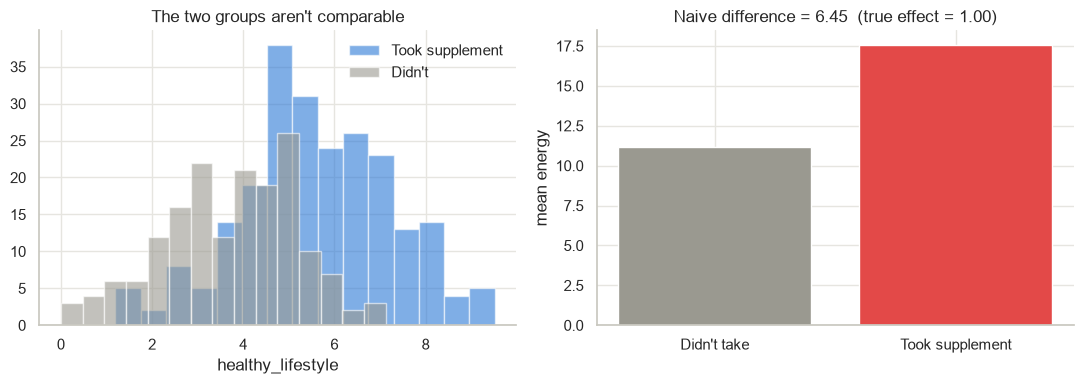

naive observational effect = 6.448   (true effect = 1.00)


In [3]:
naive_obs_effect = obs.loc[obs["took_supplement"] == 1, "energy"].mean() - obs.loc[obs["took_supplement"] == 0, "energy"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(obs.loc[obs["took_supplement"] == 1, "healthy_lifestyle"], bins=15, alpha=0.6, color=ACCENT, label="Took supplement")
axes[0].hist(obs.loc[obs["took_supplement"] == 0, "healthy_lifestyle"], bins=15, alpha=0.6, color=NEUTRAL, label="Didn't")
axes[0].set_xlabel("healthy_lifestyle")
axes[0].set_title("The two groups aren't comparable")
axes[0].legend(frameon=False)

axes[1].bar(["Didn't take", "Took supplement"], [obs.loc[obs["took_supplement"] == 0, "energy"].mean(), obs.loc[obs["took_supplement"] == 1, "energy"].mean()], color=[NEUTRAL, NEGATIVE])
axes[1].set_ylabel("mean energy")
axes[1].set_title(f"Naive difference = {naive_obs_effect:.2f}  (true effect = {TRUE_EFFECT:.2f})")

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"naive observational effect = {naive_obs_effect:.3f}   (true effect = {TRUE_EFFECT:.2f})")

### Now randomize the assignment — nothing else changes

Same 400 people, same `healthy_lifestyle` values, same true effect and formula. The only thing that changes: instead of people choosing whether to take the supplement (correlated with their lifestyle), we flip a coin for each person.

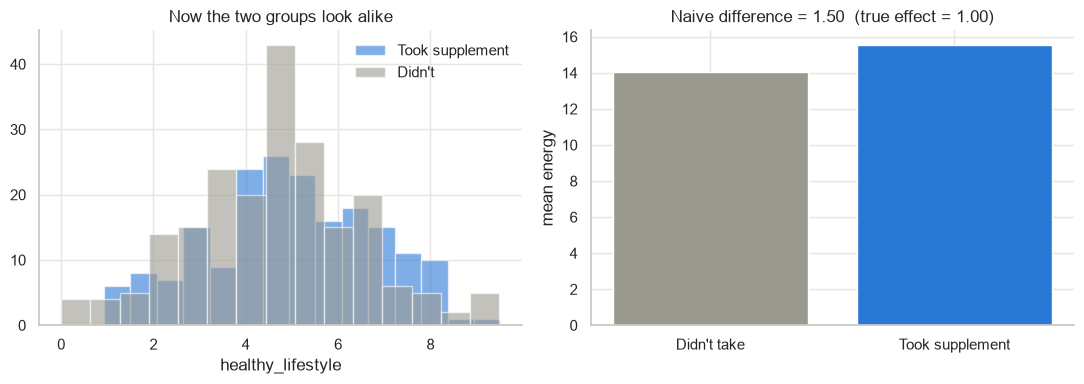

naive randomized effect = 1.501   (true effect = 1.00)


In [4]:
took_supplement_rct = rng.binomial(1, 0.5, n_people)  # a coin flip, independent of healthy_lifestyle
energy_rct = TRUE_EFFECT * took_supplement_rct + BETA_LIFESTYLE * healthy_lifestyle + rng.normal(0, NOISE_SD, n_people)

rct = pd.DataFrame({"healthy_lifestyle": healthy_lifestyle, "took_supplement": took_supplement_rct, "energy": energy_rct})
naive_rct_effect = rct.loc[rct["took_supplement"] == 1, "energy"].mean() - rct.loc[rct["took_supplement"] == 0, "energy"].mean()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(rct.loc[rct["took_supplement"] == 1, "healthy_lifestyle"], bins=15, alpha=0.6, color=ACCENT, label="Took supplement")
axes[0].hist(rct.loc[rct["took_supplement"] == 0, "healthy_lifestyle"], bins=15, alpha=0.6, color=NEUTRAL, label="Didn't")
axes[0].set_xlabel("healthy_lifestyle")
axes[0].set_title("Now the two groups look alike")
axes[0].legend(frameon=False)

axes[1].bar(["Didn't take", "Took supplement"], [rct.loc[rct["took_supplement"] == 0, "energy"].mean(), rct.loc[rct["took_supplement"] == 1, "energy"].mean()], color=[NEUTRAL, ACCENT])
axes[1].set_ylabel("mean energy")
axes[1].set_title(f"Naive difference = {naive_rct_effect:.2f}  (true effect = {TRUE_EFFECT:.2f})")

for ax in axes:
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

print(f"naive randomized effect = {naive_rct_effect:.3f}   (true effect = {TRUE_EFFECT:.2f})")

That's the entire mechanism behind why randomization works: assignment is now independent of `healthy_lifestyle` by construction, so the two groups end up with statistically similar lifestyle distributions — not just for this one confounder, but for *every* confounder, measured or not, known or not. Nothing needs to be controlled for, because nothing is unbalanced between the groups in the first place.

One more distinction worth being precise about: the randomized estimate above isn't dead-on `1.0` — it's off by ordinary sampling noise, the same kind covered in notebook 2. That noise shrinks with more data. The observational bias does not — it's systematic, not random, so throwing more people at it only makes the wrong answer more confident:

In [5]:
n_big = 20_000
hl_big = np.clip(rng.normal(5, 2, n_big), 0, 10)

logit_big = -3 + 0.7 * hl_big
took_obs_big = rng.binomial(1, 1 / (1 + np.exp(-logit_big)))
energy_obs_big = TRUE_EFFECT * took_obs_big + BETA_LIFESTYLE * hl_big + rng.normal(0, NOISE_SD, n_big)
obs_big_effect = energy_obs_big[took_obs_big == 1].mean() - energy_obs_big[took_obs_big == 0].mean()

took_rct_big = rng.binomial(1, 0.5, n_big)
energy_rct_big = TRUE_EFFECT * took_rct_big + BETA_LIFESTYLE * hl_big + rng.normal(0, NOISE_SD, n_big)
rct_big_effect = energy_rct_big[took_rct_big == 1].mean() - energy_rct_big[took_rct_big == 0].mean()

print(f"{'':>20}  n=400{'':>10}  n=20,000")
print(f"{'observational':>20}  {naive_obs_effect:>10.3f}  {obs_big_effect:>10.3f}   <- still nowhere near {TRUE_EFFECT:.2f}, more data doesn't help")
print(f"{'randomized':>20}  {naive_rct_effect:>10.3f}  {rct_big_effect:>10.3f}   <- converges to {TRUE_EFFECT:.2f}")

                      n=400            n=20,000
       observational       6.448       6.993   <- still nowhere near 1.00, more data doesn't help
          randomized       1.501       1.030   <- converges to 1.00


### When you can't randomize: propensity score matching

Sometimes running an experiment genuinely isn't possible — you're stuck with the observational data someone who took the supplement voluntarily generated. The best available fallback: estimate each person's **propensity score** — their probability of taking the supplement, given `healthy_lifestyle` — then match each supplement-taker to the control person with the closest propensity score. Comparing outcomes *within matched pairs* approximates "people who looked equally likely to take it, but happened to land on different sides."

In [6]:
X_ps = sm.add_constant(obs["healthy_lifestyle"])
propensity_model = sm.Logit(obs["took_supplement"], X_ps).fit(disp=0)
obs["propensity"] = propensity_model.predict(X_ps)

treated = obs[obs["took_supplement"] == 1]
control = obs[obs["took_supplement"] == 0]

CALIPER = 0.02  # only accept a match if propensity scores are within this distance
matched_diffs = []
for _, person in treated.iterrows():
    dists = (control["propensity"] - person["propensity"]).abs()
    if dists.min() <= CALIPER:
        best_match = control.loc[dists.idxmin()]
        matched_diffs.append(person["energy"] - best_match["energy"])

matched_effect = np.mean(matched_diffs)
print(f"matched {len(matched_diffs)} of {len(treated)} treated people within a {CALIPER} propensity caliper")
print()
print(f"naive observational effect        = {naive_obs_effect:.3f}")
print(f"propensity-matched effect         = {matched_effect:.3f}")
print(f"true effect                       = {TRUE_EFFECT:.2f}")

matched 199 of 231 treated people within a 0.02 propensity caliper

naive observational effect        = 6.448
propensity-matched effect         = 1.426
true effect                       = 1.00


Much closer to the truth than the naive comparison — but notice two honest limits, visible right in the numbers above. First, some treated people got dropped entirely (no control person looked similar enough within the caliper) — matching can only compare people who have a plausible match, which silently changes *who* the estimate is even about. Second, matching only balances the confounders you measured and fed into the propensity model — `healthy_lifestyle`, here. Any confounder you didn't think to measure is just as invisible to matching as it is to regression. Randomization is the only method on this page that handles unmeasured confounders too, because it doesn't need to know what they are.

## Part B — The reveal

Every notebook so far has deliberately not opened this file. Here it is: the actual generating process behind `sales_activity_data.csv`, written down before any of the analysis happened.

In [7]:
with open(DATA_DIR / "ground_truth.json") as f:
    ground_truth = json.load(f)

answer_key = pd.DataFrame([
    {"activity": name, "true_relationship": info["relationship"], "true_effect_per_unit": info["true_effect_per_unit"], "mechanism": info["mechanism"]}
    for name, info in ground_truth["activities"].items()
])
answer_key

,activity,true_relationship,true_effect_per_unit,mechanism
0,demos_given,causal,1500,Directly adds to revenue in the generating for...
1,proposals_sent,causal,2500,Directly adds to revenue in the generating for...
2,crm_usage,confounded,0,Driven by territory_z (better territories mean...
3,calls_made,reverse_causal,0,Computed FROM revenue (reps with stronger pipe...
4,training_completed,noise,0,Drawn independently of everything else. No rel...


Checking this against four notebooks of reasoning: `crm_usage` really was confounded by territory, exactly as notebook 3 concluded. `training_completed` really was pure noise. `demos_given` and `proposals_sent` really are causal. And `calls_made` — the one notebook 4 explicitly said couldn't be resolved — really is **reverse-causal**: it's computed *from* revenue in the generating process, not the other way round. Notebook 4 was right to leave it unresolved; the honest answer was that the data alone couldn't say.

Knowing the *mechanism*, though, means we now know the *formula* — which means we can do something no real analyst ever gets to do: simulate the experiment that would have settled it.

### Simulating the randomized experiment we couldn't run

Here's the idea: notebook 1's revenue formula only ever used three ingredients — `demos_given`, `proposals_sent`, and territory. Nothing else, including `calls_made`, ever entered it. Since we now know that formula exactly, we can literally run Part A's randomization trick on each activity:

1. Take one activity and **shuffle its values across reps** — same real numbers, randomly reassigned, exactly like breaking the link between temperature and drownings in notebook 3. This is what "randomly assigning" the activity would look like.
2. Recompute what revenue *would have been*, using the true formula and the (now-randomized) activity.
3. Correlate the randomized activity against this simulated revenue.

Because the activity was just randomly reassigned, this correlation can't be confounded and can't be reverse-caused by anything — there's nothing left for it to be except the real, direct effect (or the absence of one).

In [8]:
df = pd.read_csv(DATA_DIR / "sales_activity_data.csv")

TRUE_INTERCEPT = ground_truth["revenue_model"]["intercept"]
TRUE_NOISE_SD = ground_truth["revenue_model"]["noise_sd"]
TRUE_BETA_DEMOS = ground_truth["activities"]["demos_given"]["true_effect_per_unit"]
TRUE_BETA_PROPOSALS = ground_truth["activities"]["proposals_sent"]["true_effect_per_unit"]
TRUE_BETA_TERRITORY = ground_truth["confounder"]["true_effect_per_unit_z"]

# recover the original standardized territory_z from the public territory_score (see ground_truth.json's note)
territory_z = ((df["territory_score"] - 5) / 2).to_numpy()


def true_revenue_formula(demos, proposals, territory_z, rng):
    """The actual notebook-1 generating formula — the one thing no real analyst ever gets to see."""
    noise = rng.normal(0, TRUE_NOISE_SD, len(demos))
    revenue = TRUE_INTERCEPT + TRUE_BETA_DEMOS * demos + TRUE_BETA_PROPOSALS * proposals + TRUE_BETA_TERRITORY * territory_z + noise
    return np.clip(revenue, 0, None)


def simulate_intervention(activity, rng):
    """Randomly reassign `activity` across reps, recompute revenue via the true formula, and see what shows up."""
    demos = df["demos_given"].to_numpy(dtype=float).copy()
    proposals = df["proposals_sent"].to_numpy(dtype=float).copy()
    randomized_activity = rng.permutation(df[activity].to_numpy())

    # only demos_given and proposals_sent are actually in the formula — swap in the randomized version when testing them
    if activity == "demos_given":
        demos = randomized_activity.astype(float)
    elif activity == "proposals_sent":
        proposals = randomized_activity.astype(float)

    simulated_revenue = true_revenue_formula(demos, proposals, territory_z, rng)
    r, p = stats.pearsonr(randomized_activity, simulated_revenue)
    slope = stats.linregress(randomized_activity, simulated_revenue).slope
    return randomized_activity, simulated_revenue, r, p, slope

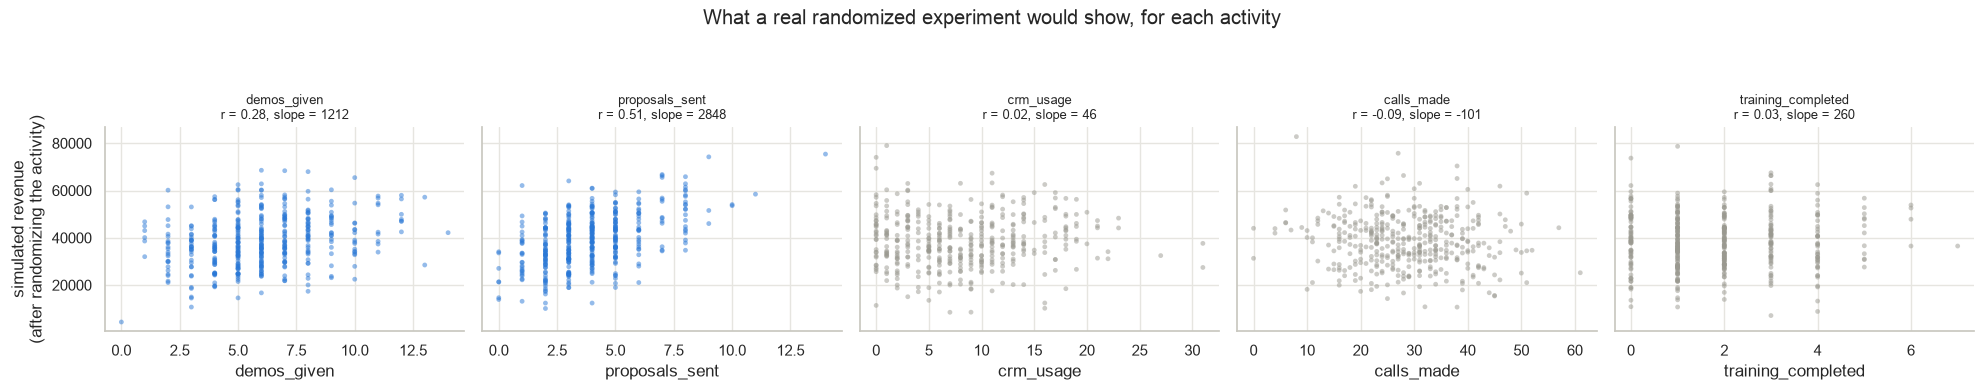

In [9]:
activity_cols = ["demos_given", "proposals_sent", "crm_usage", "calls_made", "training_completed"]

fig, axes = plt.subplots(1, 5, figsize=(20, 3.6), sharey=True)
rct_results = {}
for ax, activity in zip(axes, activity_cols):
    randomized_activity, simulated_revenue, r, p, slope = simulate_intervention(activity, rng)
    rct_results[activity] = {"r": r, "p": p, "slope": slope}
    color = ACCENT if p < 0.01 else NEUTRAL
    ax.scatter(randomized_activity, simulated_revenue, s=12, alpha=0.5, color=color, edgecolor="none")
    ax.set_title(f"{activity}\nr = {r:.2f}, slope = {slope:.0f}", fontsize=9)
    ax.set_xlabel(activity)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
axes[0].set_ylabel("simulated revenue\n(after randomizing the activity)")
fig.suptitle("What a real randomized experiment would show, for each activity", y=1.08)
plt.tight_layout()
plt.show()

`demos_given` and `proposals_sent` keep a real, significant dose-response relationship after randomization — nothing to be confounded or reverse-caused by anymore, and a relationship still shows up. `crm_usage`, `calls_made`, and `training_completed` all flatten out to noise. That's `calls_made`'s cliffhanger from notebook 4, resolved: once its natural link to revenue is broken by randomization, there's nothing left. It was never a driver — the correlation was revenue causing calls, not calls causing revenue.

### The final comparison

One table, pulling together every estimate this series has produced for each activity: the naive correlation (notebook 2), the territory-adjusted correlation (notebook 3), the simulated true effect (just now), and the actual ground truth this was all trying to recover.

In [10]:
rows = []
for activity in activity_cols:
    naive_r = stats.pearsonr(df[activity], df["revenue"]).statistic
    resid_activity = residualize(df[activity].to_numpy(), df["territory_score"].to_numpy())
    resid_revenue = residualize(df["revenue"].to_numpy(), df["territory_score"].to_numpy())
    partial_r = stats.pearsonr(resid_activity, resid_revenue).statistic
    rows.append({
        "activity": activity,
        "naive_r (notebook 2)": naive_r,
        "territory-adjusted r (notebook 3)": partial_r,
        "simulated RCT r (this notebook)": rct_results[activity]["r"],
        "simulated RCT slope ($/unit)": rct_results[activity]["slope"],
        "ground-truth relationship": ground_truth["activities"][activity]["relationship"],
        "ground-truth $/unit": ground_truth["activities"][activity]["true_effect_per_unit"],
    })

final_table = pd.DataFrame(rows).sort_values("naive_r (notebook 2)", key=abs, ascending=False).reset_index(drop=True)
final_table

,activity,naive_r (notebook 2),territory-adjusted r (notebook 3),simulated RCT r (this notebook),simulated RCT slope ($/unit),ground-truth relationship,ground-truth $/unit
0,crm_usage,0.610302,0.020617,0.024930,46.351844,confounded,0
1,proposals_sent,0.419147,0.630669,0.511382,2847.587533,causal,2500
2,calls_made,0.406143,0.357679,-0.091332,-101.265716,reverse_causal,0
3,demos_given,0.385986,0.475793,0.278450,1212.261962,causal,1500
4,training_completed,0.034536,-0.007120,0.032557,259.690272,noise,0


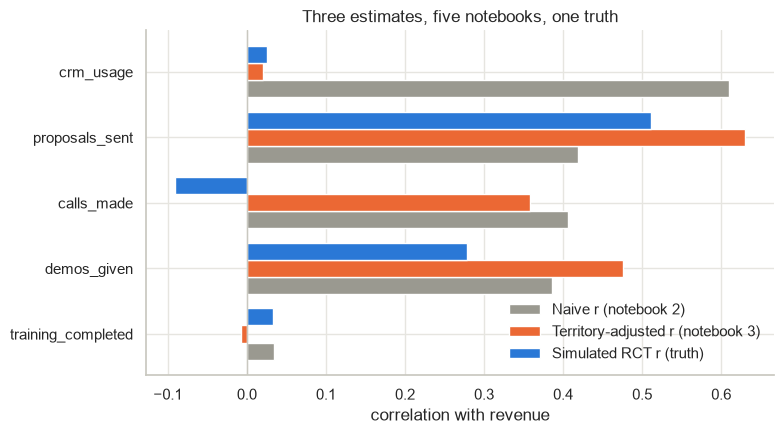

In [11]:
plot_order = final_table.sort_values("naive_r (notebook 2)")["activity"]
y_pos = np.arange(len(plot_order))
height = 0.26

fig, ax = plt.subplots(figsize=(8, 4.5))
t = final_table.set_index("activity").loc[plot_order]
ax.barh(y_pos - height, t["naive_r (notebook 2)"], height=height, color=NEUTRAL, label="Naive r (notebook 2)")
ax.barh(y_pos, t["territory-adjusted r (notebook 3)"], height=height, color="#eb6834", label="Territory-adjusted r (notebook 3)")
ax.barh(y_pos + height, t["simulated RCT r (this notebook)"], height=height, color=ACCENT, label="Simulated RCT r (truth)")

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_order)
ax.axvline(0, color="#c9c8c0", linewidth=1)
ax.set_xlabel("correlation with revenue")
ax.set_title("Three estimates, five notebooks, one truth")
ax.legend(frameon=False, loc="lower right")
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## The series, in one picture

- **`crm_usage`** — the naive bar is the tallest of all five. Territory-adjusted, it collapses. Simulated-RCT, it's flat. A confound, start to finish — and the one activity where trusting naive correlation would have been the most expensive mistake, since it looked like the *best* investment of the five.
- **`training_completed`** — near zero everywhere. Nothing to explain away.
- **`demos_given`, `proposals_sent`** — present at every stage, and *strengthen* rather than weaken once territory is controlled for. The simulated RCT confirms what notebooks 2 and 3 already pointed to.
- **`calls_made`** — naive and territory-adjusted bars both stay substantial, indistinguishable in shape from the two real drivers. Only the simulated RCT — the one estimate observational data could never produce on its own — reveals it's flat. This is the entire point of the series in a single bar: **two activities can look statistically identical on every check available to observational data, and still differ completely in whether either one actually works.**

That gap is exactly what separates correlation from causation — not a matter of using a fancier statistical test, but of what kind of evidence you have at all. Notebooks 2 through 4 are the full toolkit for reasoning as far as observational data can take you: honestly, rigorously, and with real limits. Closing that last gap took something categorically different — not a better regression, but an intervention. In a real sales org, that means an actual experiment: randomly assign a change in behavior (a call-volume target, a demo quota) to one group and not another, and measure what happens. Everything in this series was building toward recognizing exactly when that step stops being optional.